In [1]:
import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)
import torch
import os

In [2]:
#hide
! [ -e /content ] && pip install -Uqq fastbook
import fastbook
fastbook.setup_book()

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 719.8/719.8 kB 11.4 MB/s eta 0:00:00 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 124.1/124.1 kB 7.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 246.9/246.9 kB 14.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.6/1.6 MB 40.8 MB/s eta 0:00:00:00:01
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
bigframes 2.31.0 requires google-cloud-bigquery-storage<3.0.0,>=2.30.0, which is not installed.


**Background**

Each image has 784 pixels and is modelled in the csv where each row denotes an image.

ith column of the csv files represents the ith pixel brightness(between 1-255) in the image

**Data extraction**

We will extract from fashion-mnist_test.csv

Let's extract a tuple of two tensors - one for the image data, and the other for the labels.

The first tensor would be a rank 2 tensor, where the ith row would be the pixel values(784 entries) of the ith image

The second tensor would be a rank 1 tensor, where the ith entry would be the label(0-9) for the ith image.


In [3]:

pathTrainingFile=None
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        if filename =="fashion-mnist_train.csv":
            df=pd.read_csv(os.path.join(dirname, filename))

tensorData= torch.tensor(df.to_numpy()) 

#Add a column of all 1's for bias term so the computation becomes a matrix multiplication
ones = torch.ones(tensorData.size(0), 1)

tensorData=torch.cat((tensorData, ones), dim=1)

In [4]:
pathTrainingFile=None
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        if filename =="fashion-mnist_test.csv":
            df=pd.read_csv(os.path.join(dirname, filename))

testData = torch.tensor(df.to_numpy()) 

#Add a column of all 1's for bias term so the computation becomes a matrix multiplication
ones = torch.ones(testData.size(0), 1)

testData=torch.cat((testData, ones), dim=1)


In [5]:
assert tensorData.shape==(60000, 786)
assert testData.shape==(10000, 786)

In [6]:
indices = torch.randperm(tensorData.shape[0])
shuffledTensorData=tensorData[indices]
assert shuffledTensorData.shape==(60000, 786)


#Verifying row sorting retains the same data for 1 st column
firstColumnOfShuffled, indices=torch.sort(shuffledTensorData[:, 0])

firstColumnOfOriginal, indices=torch.sort(tensorData[:, 0])

assert firstColumnOfShuffled.ndim==1
assert firstColumnOfOriginal.ndim==1

assert torch.equal(firstColumnOfShuffled, firstColumnOfOriginal)

Seperating into training and validation

In [7]:
SIZE=60000
TRAINING_SET_RATIO=0.8
trainingData=shuffledTensorData[0:int(SIZE*TRAINING_SET_RATIO),:]
validationData=shuffledTensorData[int(SIZE*TRAINING_SET_RATIO):,:]

assert trainingData.shape[0]+validationData.shape[0]==60000
assert trainingData.ndim==2
assert validationData.ndim==2

In [8]:
#Split the data by remove the first column of a matrix into a label matrix

trainingImageData=trainingData[:, 1:]

trainingLabels=trainingData[:, 0]

assert trainingImageData.shape==(trainingData.shape[0], 785)
assert trainingImageData.ndim==2
assert trainingLabels.shape==(trainingData.shape[0],)
assert trainingLabels.ndim==1

In [9]:
#Convert training labels to a rank 1 tensor of 10 entries where ith entry is 1 if the label is i, else it is zero

transformedTrainingLabels=[]

for label in trainingLabels:
    transformedLabel=[0]*10
    transformedLabel[int(label.item())]=1
    transformedTrainingLabels.append(transformedLabel)


transformedTrainingLabels=torch.tensor(transformedTrainingLabels)


assert transformedTrainingLabels.ndim==2
assert transformedTrainingLabels.shape == (trainingLabels.shape[0], 10)

In [10]:
#Split the data by remove the first column of a matrix into a label matrix

validationImageData=validationData[:, 1:]

validationLabels=validationData[:, 0]

assert validationImageData.shape==(validationData.shape[0], 785)
assert validationImageData.ndim==2
assert validationLabels.shape==(validationData.shape[0],)
assert validationLabels.ndim==1

In [11]:

transformedValidationLabels=[]

for label in validationLabels:
    transformedLabel=[0]*10
    transformedLabel[int(label.item())]=1
    transformedValidationLabels.append(transformedLabel)


transformedValidationLabels=torch.tensor(transformedValidationLabels)


assert transformedValidationLabels.ndim==2
assert transformedValidationLabels.shape == (validationLabels.shape[0], 10)

In [12]:
from torch.utils.data import DataLoader

BATCH_SIZE=2000
dset=list(zip(trainingImageData, transformedTrainingLabels))
dl = DataLoader(dset, BATCH_SIZE, shuffle=True)



**Model architecture**

Our first model would be a single layer neural net with 10 neurons. Each neuron's activation would give us the probability of our model predicting it is category i with probability p_i


Each neuron would have 784 params, one per pixel and 1 param for bias.


We would leverage the mean square error loss here

In [37]:
def mse(prediction, target):
    prediction = prediction.relu()
    return ((prediction - target)**2).mean()

In [14]:
sampleOutput=torch.rand(10)
target=torch.tensor([1, 0, 0, 0, 0, 0, 0, 0, 0, 0])

loss=mse(sampleOutput, target)
print(loss.ndim)

0


In [15]:
def compute_accuracy(prediction, testLabels):
    matches = 0
    total = len(testLabels)
    
    for i, row in enumerate(prediction):
        predicted_class = row.argmax()
        
        if predicted_class == testLabels[i]:
            matches += 1
            
    return matches / total

**Learning loop**

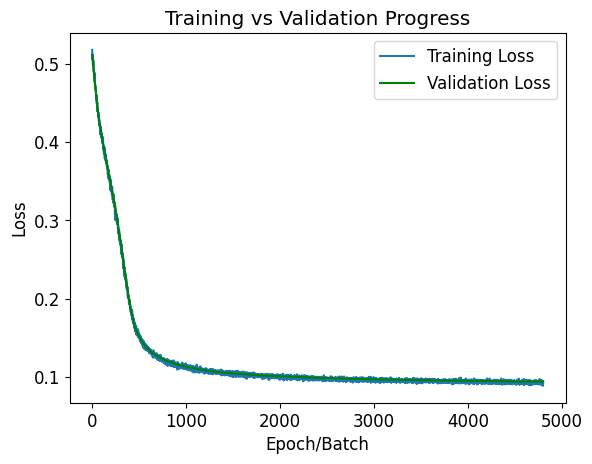

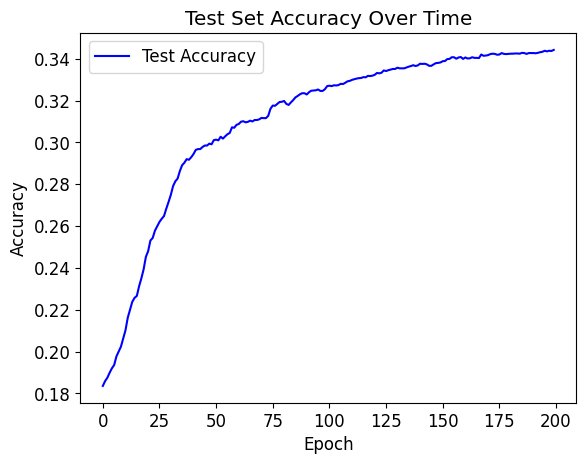

In [16]:
#modelParams would be a (784+1)*10 matrix 

modelParams=torch.randn(785, 10).requires_grad_()

def f(params, inp):
    return inp@params

losses = []
valLosses = []
testAccuracies=[]
import matplotlib.pyplot as plt
LEARNING_RATE=1e-1
EPOCHS=200

testImageData=testData[:, 1:]
testLabels=testData[:, 0]
assert testImageData.shape == (10000, 785)
assert testLabels.shape == (10000,)



for i in range(0, EPOCHS):
    #One epoch loop below
    for inp, output in dl:
        assert inp.shape == (BATCH_SIZE, 785)
        assert output.shape == (BATCH_SIZE, 10)
        assert modelParams.shape == (785, 10)
        preds=f(modelParams, inp)
        assert preds.shape == (BATCH_SIZE, 10)
        loss=mse(preds, output)
        assert loss.ndim == 0
        losses.append(loss.item())
        loss.backward()
        modelParams.data-=LEARNING_RATE*modelParams.grad
        modelParams.grad.zero_()
        validationPreds=f(modelParams, validationImageData)
        assert validationPreds.shape == (60000-trainingData.shape[0], 10)
        validationLoss=mse(validationPreds, transformedValidationLabels)
        valLosses.append(validationLoss.item())

    testPreds=f(modelParams, testImageData)
    assert testPreds.shape == (10000, 10)
    testAccuracy=compute_accuracy(testPreds, testLabels)
    testAccuracies.append(testAccuracy)
    

# 3. Plot after the loop finishes
plt.plot(losses, label='Training Loss')
plt.plot(valLosses, color='green', label='Validation Loss')
plt.xlabel('Epoch/Batch')
plt.ylabel('Loss')
plt.title('Training vs Validation Progress')
plt.legend()
plt.show()

# Create a new figure for accuracy
plt.figure() 
plt.plot(testAccuracies, color='blue', label='Test Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.title('Test Set Accuracy Over Time')
plt.legend()
plt.show()


    

Seems like we are hitting a wall at 34% accuracy, we improved about 16%. Previously we hit a wall at 20% accuracy, when we started of 5% accuracy.

There are couple observations:

a) Our model has no non-linearity discounting the sigmoid we apply before making prediction. 


Let's keep the middle layer neuron count minimal to see if a rise in accuracy keep be attributed to the non-linearity introduction
Let's experiment with (a) where we have 785 neurons in the first layer, and 2 neurons in the middle, and an output layer of 10 neurons.






Learning loop

In [17]:
firstToSecondParams=torch.randn(785, 40).requires_grad_()

secondToThirdParams=torch.randn(40, 10).requires_grad_()

def rawOut(firstP, secondP, inp):
    middle=(inp@firstP).sigmoid()
    return middle@secondP


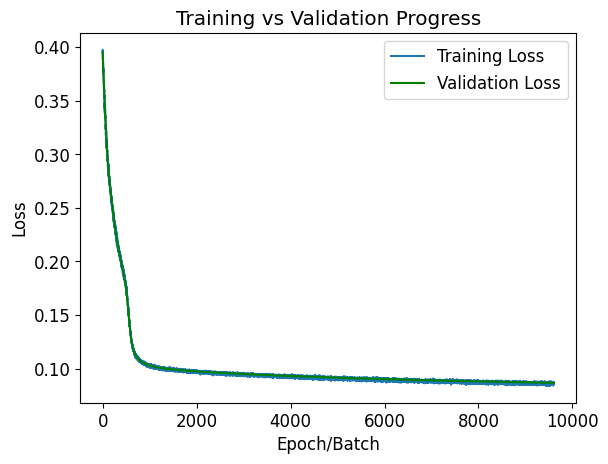

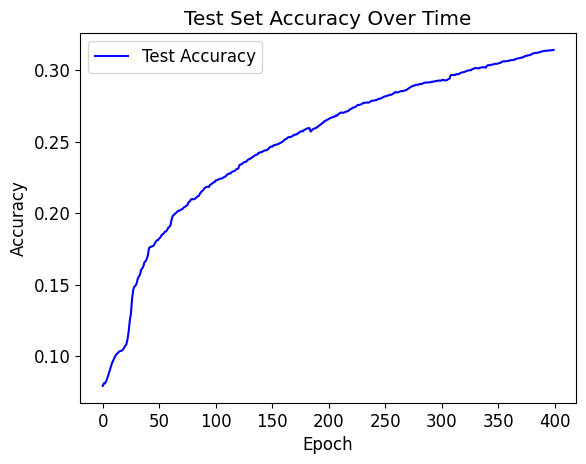

In [18]:

losses = []
valLosses = []
testAccuracies=[]
import matplotlib.pyplot as plt
LEARNING_RATE=1e-1
EPOCHS=400

testImageData=testData[:, 1:]
testLabels=testData[:, 0]
assert testImageData.shape == (10000, 785)
assert testLabels.shape == (10000,)



for i in range(0, EPOCHS):
    #One epoch loop below
    for inp, output in dl:
        assert inp.shape == (BATCH_SIZE, 785)
        assert output.shape == (BATCH_SIZE, 10)
        preds=rawOut(firstToSecondParams, secondToThirdParams, inp)
        assert preds.shape == (BATCH_SIZE, 10)
        loss=mse(preds, output)
        assert loss.ndim == 0
        losses.append(loss.item())
        loss.backward()
        firstToSecondParams.data-=LEARNING_RATE*firstToSecondParams.grad
        secondToThirdParams.data-=LEARNING_RATE*secondToThirdParams.grad
        firstToSecondParams.grad.zero_()
        secondToThirdParams.grad.zero_()
        validationPreds=rawOut(firstToSecondParams, secondToThirdParams, validationImageData)
        assert validationPreds.shape == (60000-trainingData.shape[0], 10)
        validationLoss=mse(validationPreds, transformedValidationLabels)
        valLosses.append(validationLoss.item())

    testPreds=rawOut(firstToSecondParams, secondToThirdParams, testImageData)
    assert testPreds.shape == (10000, 10)
    testAccuracy=compute_accuracy(testPreds, testLabels)
    testAccuracies.append(testAccuracy)
    

# 3. Plot after the loop finishes
plt.plot(losses, label='Training Loss')
plt.plot(valLosses, color='green', label='Validation Loss')
plt.xlabel('Epoch/Batch')
plt.ylabel('Loss')
plt.title('Training vs Validation Progress')
plt.legend()
plt.show()

# Create a new figure for accuracy
plt.figure() 
plt.plot(testAccuracies, color='blue', label='Test Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.title('Test Set Accuracy Over Time')
plt.legend()
plt.show()


Observations:

1) Having a middle layer of two neurons gave us even lower accuracy.
2) Having a middle layer of 100 just keeps the same accuracy, I think some technical difficulty is happening and learning is not happening.
3) Having a middle layer of 30 neurons, for 200 epochs, got it is 0.42ish accuracy.
4) Sometimes we get stuck in this weird area where 

Normalizing because large pixel values might be putting things in dead regions.

Using Cross entropy error and adding softmax.

In [26]:
def crossEntropyLoss(preds, target):
    # 1. Apply Softmax to get probabilities (dim=1 is the class dimension)
    # Note: Using .clamp prevents log(0) which leads to NaNs
    probs = preds.softmax(dim=1)
    
    # 2. Formula: -sum(target * log(probs)) / batch_size
    loss = -(target * torch.log(probs.clamp(min=1e-9))).sum(dim=1).mean()
    return loss

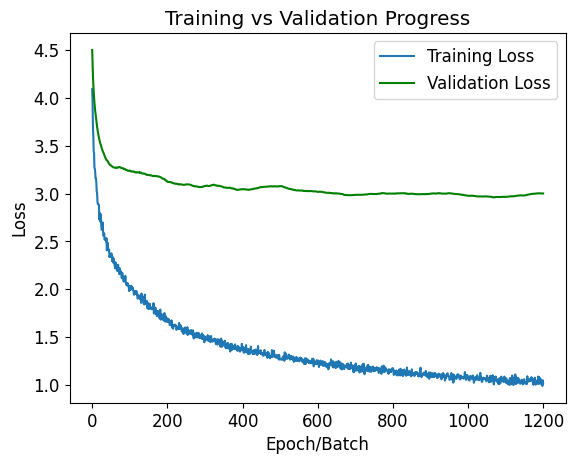

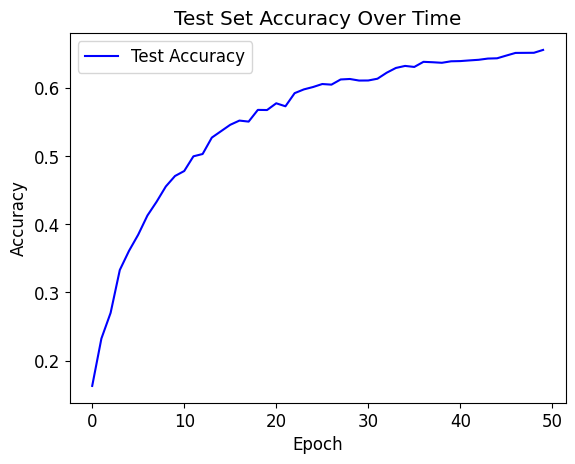

In [41]:
firstToSecondParams=torch.randn(785, 20).requires_grad_()

secondToThirdParams=torch.randn(20, 10).requires_grad_()


losses = []
valLosses = []
testAccuracies=[]
import matplotlib.pyplot as plt
LEARNING_RATE=1e-1
EPOCHS=50

testImageData=testData[:, 1:]
testLabels=testData[:, 0]
assert testImageData.shape == (10000, 785)
assert testLabels.shape == (10000,)

trainingImageData = trainingImageData / 255.0
validationImageData = validationImageData / 255.0
testImageData = testImageData / 255.0

for i in range(0, EPOCHS):
    #One epoch loop below
    for inp, output in dl:
        assert inp.shape == (BATCH_SIZE, 785)
        assert output.shape == (BATCH_SIZE, 10)
        preds=rawOut(firstToSecondParams, secondToThirdParams, inp)
        assert preds.shape == (BATCH_SIZE, 10)
        loss=crossEntropyLoss(preds, output)
        assert loss.ndim == 0
        losses.append(loss.item())
        loss.backward()
        firstToSecondParams.data-=LEARNING_RATE*firstToSecondParams.grad
        secondToThirdParams.data-=LEARNING_RATE*secondToThirdParams.grad
        firstToSecondParams.grad.zero_()
        secondToThirdParams.grad.zero_()
        validationPreds=rawOut(firstToSecondParams, secondToThirdParams, validationImageData)
        assert validationPreds.shape == (60000-trainingData.shape[0], 10)
        validationLoss=crossEntropyLoss(validationPreds, transformedValidationLabels)
        valLosses.append(validationLoss.item())

    testPreds=rawOut(firstToSecondParams, secondToThirdParams, testImageData)
    assert testPreds.shape == (10000, 10)
    testAccuracy=compute_accuracy(testPreds, testLabels)
    testAccuracies.append(testAccuracy)
    

# 3. Plot after the loop finishes
plt.plot(losses, label='Training Loss')
plt.plot(valLosses, color='green', label='Validation Loss')
plt.xlabel('Epoch/Batch')
plt.ylabel('Loss')
plt.title('Training vs Validation Progress')
plt.legend()
plt.show()

# Create a new figure for accuracy
plt.figure() 
plt.plot(testAccuracies, color='blue', label='Test Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.title('Test Set Accuracy Over Time')
plt.legend()
plt.show()

Introducing Cross entropy with softmax was a literal phase shift!


Conclusion:

1) Introducing a hidden layer was a small bump.
2) Normalizing after did not anything.
3) However introducing softmax with cross entropy loss had a phase shift.
   i) Mumblings
      a) Softmax makes the output sum to 1, increase a value by a unit, will decrease other value.
      b) Cross entropy only focuses on the expected class predicted probability.
   2) Why
      a) Cross entropy gives bigger gradients when the model is confidently wrong - we can tweak params more efficiently.
      b) Cross entropy loss is a bigger domain, while MSE is stuck in 0-1 range.
      c) Softmax encodes what are we trying to solve : Predict which it belongs to.
      